#Tarea - Agente con ambiente Lunar Lander

In [1]:
import gymnasium as gym
import numpy as np
from random import randint

In [2]:
env= gym.make("LunarLander-v3", continuous=False, gravity=-10.0, enable_wind=False, wind_power=15.0, turbulence_power=1.5)

In [3]:
def discretizar(valor):
    # Ajustado para mapear a la nueva resolución
    # El espacio de observación para LunarLander es complejo; limitamos para evitar errores de índice
    low = env.observation_space.low
    high = env.observation_space.high
    # Reemplazar valores infinitos para el escalado
    high = np.where(high > 1e10, 5, high)
    low = np.where(low < -1e10, -5, low)

    aux = ((valor - low) / (high - low)) * (resolution - 1)
    aux = np.clip(aux, 0, resolution - 1)
    return tuple(aux.astype(np.int32))

In [4]:
def continous(indice):
  if indice == 0:
    return np.array([-1.99], dtype=np.float32)
  elif indice == 1:
    return np.array([-1.0], dtype=np.float32)
  elif indice == 2:
    return np.array([0.0], dtype=np.float32)
  elif indice == 3:
    return np.array([1.0], dtype=np.float32)
  else:
    return np.array([1.99], dtype=np.float32)

In [5]:
# Inicializar la tabla Q con 8 dimensiones para el estado + 1 para las 4 acciones discretas
resolution = 10
q_table = np.random.uniform(low=-1, high=1, size=[resolution]*8 + [4])

In [6]:
alfa = 0.1
gamma = 0.95
episodios = 10000  # Aumentamos el número de episodios
epsilon_inicial = 1.0 # Epsilon inicial para explorar
epsilon_final = 0.01  # Epsilon mínimo para asegurar algo de exploración
decay_rate = 0.001 # Tasa de decaimiento de epsilon
lista_recompenzas = []

for episodio in range(episodios):
    epsilon = epsilon_final + (epsilon_inicial - epsilon_final) * np.exp(-decay_rate * episodio)
    obs, info = env.reset()
    estado = discretizar(obs)
    final = False
    recompensa_total = 0

    if np.random.rand() < epsilon:
        # LunarLander-v3 discreto tiene 4 acciones (0, 1, 2, 3)
        accion = randint(0, 3)
    else:
        accion = np.argmax(q_table[estado])

    while not final:
        # Asegurar que la acción sea un entero estándar y esté dentro de los límites
        nuevo_obs, recompensa, terminated, truncated, info = env.step(int(accion))
        nuevo_estado = discretizar(nuevo_obs)

        # Actualizar el valor Q
        best_future_q = np.max(q_table[nuevo_estado])
        q_table[estado][accion] = q_table[estado][accion] + alfa * (recompensa + gamma * best_future_q - q_table[estado][accion])

        estado = nuevo_estado
        recompensa_total += recompensa
        final = terminated or truncated

        if np.random.rand() < epsilon:
            accion = randint(0, 3)
        else:
            accion = np.argmax(q_table[estado])

    lista_recompenzas.append(recompensa_total)
    if (episodio + 1) % 500 == 0:
        print(f"Episodio: {episodio + 1} | Recompensa promedio: {np.mean(lista_recompenzas[-100:]):.2f}")

env.close()

Episodio: 500 | Recompensa promedio: -170.27
Episodio: 1000 | Recompensa promedio: -176.56
Episodio: 1500 | Recompensa promedio: -197.26
Episodio: 2000 | Recompensa promedio: -203.68
Episodio: 2500 | Recompensa promedio: -200.57
Episodio: 3000 | Recompensa promedio: -174.35
Episodio: 3500 | Recompensa promedio: -165.25
Episodio: 4000 | Recompensa promedio: -174.61
Episodio: 4500 | Recompensa promedio: -122.72
Episodio: 5000 | Recompensa promedio: -152.41
Episodio: 5500 | Recompensa promedio: -124.37
Episodio: 6000 | Recompensa promedio: -98.11
Episodio: 6500 | Recompensa promedio: -129.28
Episodio: 7000 | Recompensa promedio: -116.85
Episodio: 7500 | Recompensa promedio: -161.76
Episodio: 8000 | Recompensa promedio: -110.83
Episodio: 8500 | Recompensa promedio: -122.86
Episodio: 9000 | Recompensa promedio: -101.89
Episodio: 9500 | Recompensa promedio: -130.29
Episodio: 10000 | Recompensa promedio: -130.82


In [17]:
#Esta visualización con el render_mode="human" solo logré verla en VScode, en Colab no se muestra
env= gym.make("LunarLander-v3", continuous=False, gravity=-10.0, enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode="human")

estado = discretizar(env.reset()[0])
final = False
recompensa_total = 0

while not final:
    # Seleccionar la mejor acción según la tabla Q entrenada
    accion = np.argmax(q_table[estado])

    # Usar la acción directamente como entero para el ambiente discreto
    nuevo_obs, recompensa, terminated, truncated, info = env.step(int(accion))
    estado = discretizar(nuevo_obs)

    recompensa_total += recompensa
    final = terminated or truncated

print(f"Recompensa de la prueba: {recompensa_total}")
env.close()

Recompensa de la prueba: -63.14764311151176


Recompensa de la prueba: -1.5087174813092616


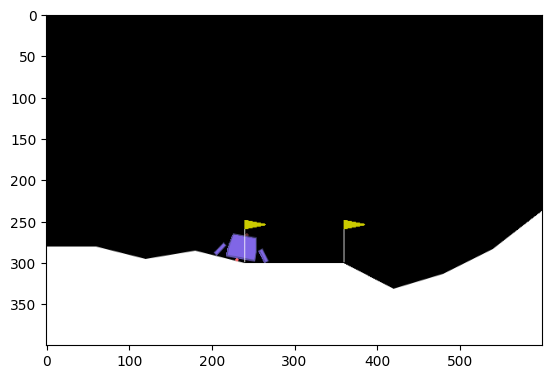

In [15]:
#Alternativa de vizualización con matplotlib en Colab

import matplotlib.pyplot as plt
from IPython import display

# Crear el ambiente para captura de video
env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0, enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode="rgb_array")

obs, info = env.reset()
estado = discretizar(obs)
final = False
recompensa_total = 0

# Preparar la visualización en Colab
img = plt.imshow(env.render())

while not final:
    # Mostrar el frame actual
    img.set_data(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

    # Seleccionar la mejor acción según la tabla Q entrenada
    accion = np.argmax(q_table[estado])

    # Ejecutar acción
    nuevo_obs, recompensa, terminated, truncated, info = env.step(int(accion))
    estado = discretizar(nuevo_obs)

    recompensa_total += recompensa
    final = terminated or truncated

print(f"Recompensa de la prueba: {recompensa_total}")
env.close()